In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller

In [41]:
data = pd.read_csv("C:\\Users\\User\\Desktop\\дані для диплому\\var1_dataset.csv")
data.head()

,Показник,ВВП України,додана вартість,експорт,kyiv_gdp,kyiv_added_price,ukr_index_house_prices,empl_kyiv,infl_ukr,unempl_kyiv,constr_ind,finance_ind,import_ua,salaries_ind_kyiv,service_ind,house_space,enterprises
0,2015Q1,375991.0,21029,249852,23600.944176,261.659539,NaN,723.2,106.400000,61.1,-44.0,-45.0,263833,119.500000,-33.0,NaN,88249.686691
1,2015Q2,456715.0,18740,250632,25205.627447,274.117887,NaN,722.5,105.533333,53.6,-46.9,-35.3,255842,122.923680,-29.1,NaN,87517.318056
2,2015Q3,566997.0,14392,266601,26824.262110,287.437229,NaN,727.1,100.166667,50.2,-44.8,-32.7,279179,126.167396,-25.7,NaN,85287.832284
3,2015Q4,588841.0,13351,278843,28399.166267,301.785345,NaN,726.9,100.466667,50.7,-38.0,-27.0,299000,129.085457,-19.7,NaN,82385.162970
4,2016Q1,455298.0,14755,252255,29944.363432,321.801694,100.9,729.3,100.500000,57.3,-34.8,-24.7,297742,131.500000,-17.7,NaN,76879.383475


In [42]:
var_data = data[['Показник', 'ВВП України', 'додана вартість', 'enterprises', 'kyiv_gdp', 'infl_ukr', 'salaries_ind_kyiv']]
var_data.head()

,Показник,ВВП України,додана вартість,enterprises,kyiv_gdp,infl_ukr,salaries_ind_kyiv
0,2015Q1,375991.0,21029,88249.686691,23600.944176,106.400000,119.500000
1,2015Q2,456715.0,18740,87517.318056,25205.627447,105.533333,122.923680
2,2015Q3,566997.0,14392,85287.832284,26824.262110,100.166667,126.167396
3,2015Q4,588841.0,13351,82385.162970,28399.166267,100.466667,129.085457
4,2016Q1,455298.0,14755,76879.383475,29944.363432,100.500000,131.500000


In [43]:
var_data = var_data.dropna()

In [44]:
var_data

,Показник,ВВП України,додана вартість,enterprises,kyiv_gdp,infl_ukr,salaries_ind_kyiv
0,2015Q1,375991.0,21029,88249.686691,23600.944176,106.400000,119.500000
1,2015Q2,456715.0,18740,87517.318056,25205.627447,105.533333,122.923680
2,2015Q3,566997.0,14392,85287.832284,26824.262110,100.166667,126.167396
3,2015Q4,588841.0,13351,82385.162970,28399.166267,100.466667,129.085457
4,2016Q1,455298.0,14755,76879.383475,29944.363432,100.500000,131.500000
5,2016Q2,535701.0,16065,75541.115794,31436.535359,101.133333,133.288162
6,2016Q3,671456.0,15935,76036.581679,32900.413467,100.466667,134.508770
7,2016Q4,722912.0,18690,77911.919052,34356.687743,101.833333,135.229906
8,2017Q1,591765.0,19240,81565.905933,36262.542363,101.300000,135.500000
9,2017Q2,664307.0,20098,84049.979226,38007.226259,101.266667,135.355643


In [45]:
var_data = var_data.set_index('Показник')
var_data.head()

,ВВП України,додана вартість,enterprises,kyiv_gdp,infl_ukr,salaries_ind_kyiv
Показник,,,,,,
2015Q1,375991.0,21029,88249.686691,23600.944176,106.400000,119.500000
2015Q2,456715.0,18740,87517.318056,25205.627447,105.533333,122.923680
2015Q3,566997.0,14392,85287.832284,26824.262110,100.166667,126.167396
2015Q4,588841.0,13351,82385.162970,28399.166267,100.466667,129.085457
2016Q1,455298.0,14755,76879.383475,29944.363432,100.500000,131.500000


In [46]:
var_data['gdp_ua'] = var_data['ВВП України'].astype(float)
var_data['gdp_ua_log'] = np.log(var_data['gdp_ua'])

var_data['enterprises'] = var_data['enterprises'].astype(float)
var_data['enterprises_log'] = np.log(var_data['enterprises'])

var_data['kyiv_gdp'] = var_data['kyiv_gdp'].astype(float)
var_data['kyiv_gdp_log'] = np.log(var_data['kyiv_gdp'])

var_data['infl_ukr'] = var_data['infl_ukr'].astype(float)
var_data['infl_ukr_log'] = np.log(var_data['infl_ukr'])

var_data['salaries_ind_kyiv'] = var_data['salaries_ind_kyiv'].astype(float)
var_data['salaries_ind_kyiv_log'] = np.log(var_data['salaries_ind_kyiv'])

In [47]:
var_data_log = var_data[['gdp_ua_log', 'enterprises_log', 'kyiv_gdp_log', 'salaries_ind_kyiv_log', 'infl_ukr_log']]
var_data_log.head()

,gdp_ua_log,enterprises_log,kyiv_gdp_log,salaries_ind_kyiv_log,infl_ukr_log
Показник,,,,,
2015Q1,12.837320,11.387925,10.069042,4.783316,4.667206
2015Q2,13.031815,11.379592,10.134823,4.811564,4.659027
2015Q3,13.248109,11.353787,10.197062,4.837610,4.606835
2015Q4,13.285911,11.319161,10.254115,4.860475,4.609826
2016Q1,13.028707,11.249993,10.307096,4.879007,4.610158


In [48]:
var_data_diff = var_data_log.diff().dropna()
var_data_diff.head()

,gdp_ua_log,enterprises_log,kyiv_gdp_log,salaries_ind_kyiv_log,infl_ukr_log
Показник,,,,,
2015Q2,0.194494,-0.008333,0.065781,0.028247,-0.008179
2015Q3,0.216294,-0.025805,0.062239,0.026046,-0.052191
2015Q4,0.037802,-0.034626,0.057053,0.022865,0.002991
2016Q1,-0.257204,-0.069168,0.052981,0.018532,0.000332
2016Q2,0.162624,-0.017561,0.048630,0.013507,0.006282


In [49]:
var_data_diff.index = pd.PeriodIndex(var_data_diff.index, freq='Q')

In [79]:
path = r'C:\Users\User\Desktop\дані для диплому\var_diff_dataset.xlsx'
var_data_diff.to_csv(path, index=True, encoding='utf-8')

In [50]:
season_dummy = pd.get_dummies(var_data_diff.index.quarter, prefix='Q',drop_first=True).astype(float)
season_dummy

,Q_2,Q_3,Q_4
0,1.0,0.0,0.0
1,0.0,1.0,0.0
2,0.0,0.0,1.0
3,0.0,0.0,0.0
4,1.0,0.0,0.0
5,0.0,1.0,0.0
6,0.0,0.0,1.0
7,0.0,0.0,0.0
8,1.0,0.0,0.0
9,0.0,1.0,0.0


In [51]:
test_size = 4
train_data = var_data_diff[:-test_size]
test_data = var_data_diff[-test_size:]

train_exog = season_dummy[:-test_size]
test_exog = season_dummy[-test_size:]

In [52]:
train_exog.index = train_data.index
test_exog.index = test_data.index

In [53]:
model_train = VAR(train_data, exog=train_exog)
order_selection = model_train.select_order(maxlags=1)
print(order_selection.summary())

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -39.58      -38.59   6.662e-18      -39.41
1     -44.91*     -42.67*  4.719e-20*     -44.53*
-------------------------------------------------


In [54]:
results_train = model_train.fit(1, trend='c')

In [55]:
lag_order = results_train.k_ar
forecast = results_train.forecast(var_data_diff.values[-lag_order:], steps=test_size, exog_future=test_exog.values)

In [56]:
from sklearn.metrics import mean_squared_error

In [84]:
for i, col in enumerate(var_data_diff.columns):
    mse = mean_squared_error(test_data.iloc[:,i], forecast[:, i])
    rmse = np.sqrt(mse)
    mae = np.mean(abs(test_data.iloc[:,i] - forecast[:, i]))
    print(f"for {col} MSE is {mse}\t")
    print(f"for {col} RMSE is {rmse}\t")
    print(f"for {col} MAE is {mae}\t")

for gdp_ua_log MSE is 0.006906451905252282	
for gdp_ua_log RMSE is 0.08310506546085071	
for gdp_ua_log MAE is 0.06085472663371828	
for enterprises_log MSE is 6.487401240459019e-05	
for enterprises_log RMSE is 0.008054440539515467	
for enterprises_log MAE is 0.007375034449936111	
for kyiv_gdp_log MSE is 0.0035068372227352548	
for kyiv_gdp_log RMSE is 0.05921855471670391	
for kyiv_gdp_log MAE is 0.053553854597328775	
for salaries_ind_kyiv_log MSE is 0.001449784072627564	
for salaries_ind_kyiv_log RMSE is 0.038076030158454864	
for salaries_ind_kyiv_log MAE is 0.03405370273772845	
for infl_ukr_log MSE is 0.00011259406435145701	
for infl_ukr_log RMSE is 0.010611035027340971	
for infl_ukr_log MAE is 0.010288861250922	


In [58]:
forecast

array([[ 0.18325042, -0.00072331,  0.09863841,  0.05964428,  0.00874216],
       [ 0.26465605,  0.00718919,  0.09741032,  0.04552852, -0.01589518],
       [ 0.08505391,  0.00701491,  0.08926236,  0.03205566, -0.00243028],
       [-0.21471205, -0.00384914,  0.08328378,  0.02160576, -0.00715992]])

In [59]:
results_train.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 14, Apr, 2026
Time:                     22:03:09
--------------------------------------------------------------------
No. of Equations:         5.00000    BIC:                   -42.6746
Nobs:                     19.0000    HQIC:                  -44.5329
Log likelihood:           336.860    FPE:                4.71858e-20
AIC:                     -44.9114    Det(Omega_mle):     6.78874e-21
--------------------------------------------------------------------
Results for equation gdp_ua_log
                              coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------------------
const                           -0.252768         0.021816          -11.586           0.000
Q_2                              0.402879         0.093016            4.331           0.000
Q_3        

In [60]:
forecast[:, 0]

array([ 0.18325042,  0.26465605,  0.08505391, -0.21471205])

In [61]:
train_data['gdp_ua_log'].values

array([ 0.19449436,  0.21629445,  0.03780219, -0.25720405,  0.16262402,
        0.22587232,  0.07383901, -0.2001779 ,  0.1156348 ,  0.22705726,
        0.06712061, -0.23310733,  0.13714277,  0.20551163,  0.05359504,
       -0.24675272,  0.12851353,  0.17605612,  0.00072728, -0.25952091])

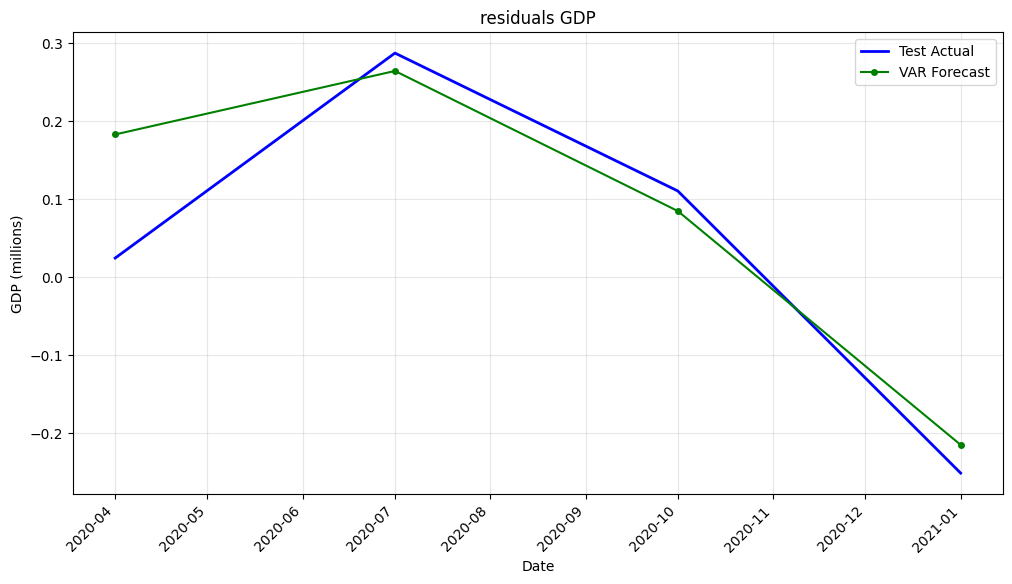

In [86]:
forecast_series = pd.Series(forecast[:, 0], index=test_data.index)

plt.figure(figsize=(12, 6))

#plt.plot(train_data.index.to_timestamp(), train_data['gdp_ua_log'], 
#         label='Train Actual', color='orange', linestyle='--')


plt.plot(test_data.index.to_timestamp(), test_data['gdp_ua_log'], 
         label='Test Actual', color='blue', linewidth=2)

plt.plot(forecast_series.index.to_timestamp(), forecast_series.values, 
         label='VAR Forecast', color='green', marker='o', markersize=4)

plt.title('residuals GDP')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.xlabel('Date')
plt.ylabel('GDP (millions)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [88]:
last_log = var_data_log['gdp_ua_log'].iloc[-5]
last_log

13.662842944516873

In [89]:
last_log = var_data_log['gdp_ua_log'].iloc[-5]
forecast_log = last_log + forecast_series.cumsum()
forecast_real = np.exp(forecast_log)

print(forecast_real)

Показник
2020Q2    1.031055e+06
2020Q3    1.343447e+06
2020Q4    1.462713e+06
2021Q1    1.180078e+06
Freq: Q-DEC, dtype: float64


In [90]:
forecast_series.cumsum()

Показник
2020Q2    0.183250
2020Q3    0.447906
2020Q4    0.532960
2021Q1    0.318248
Freq: Q-DEC, dtype: float64

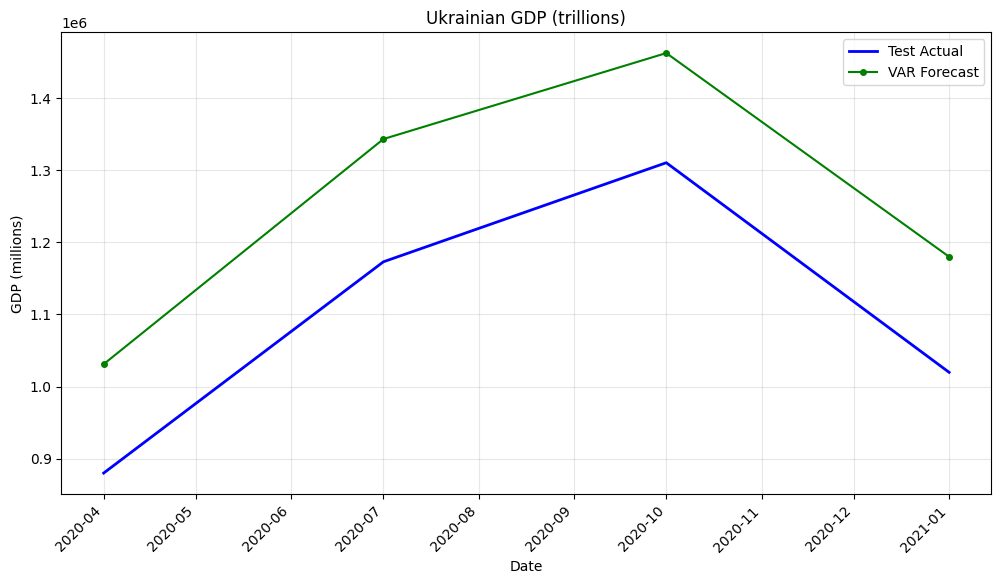

In [91]:

plt.figure(figsize=(12, 6))

#plt.plot(train_data.index.to_timestamp(), var_data['ВВП України'][1:-4], 
#         label='Train Actual', color='orange', linestyle='--')

plt.plot(test_data.index.to_timestamp(), var_data['ВВП України'][-4:], 
         label='Test Actual', color='blue', linewidth=2)

plt.plot(forecast_series.index.to_timestamp(), forecast_real.values, 
         label='VAR Forecast', color='green', marker='o', markersize=4)

plt.title('Ukrainian GDP (trillions)')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.xlabel('Date')
plt.ylabel('GDP (millions)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

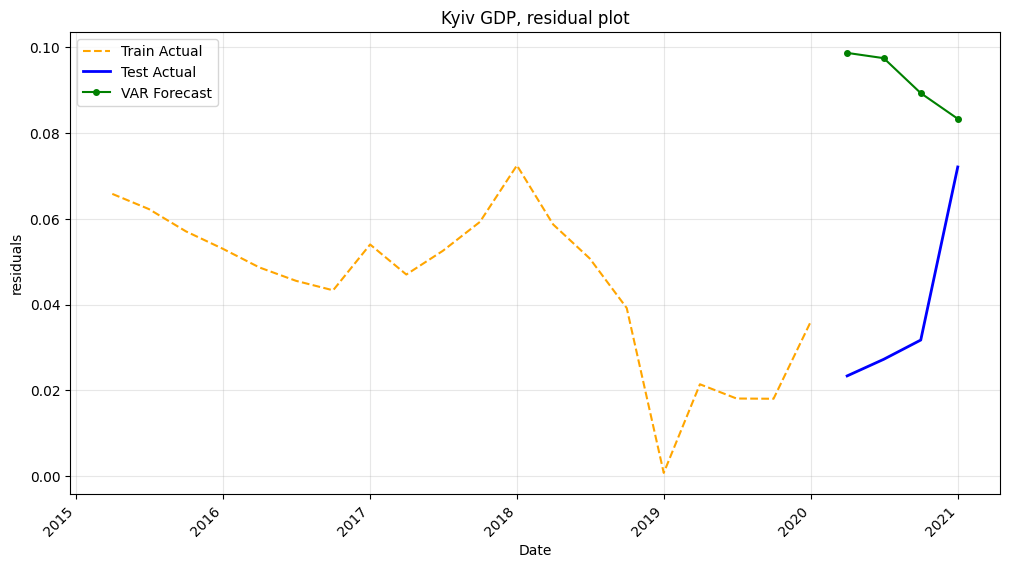

In [67]:
forecast_series = pd.Series(forecast[:, 2], index=test_data.index)

plt.figure(figsize=(12, 6))

plt.plot(train_data.index.to_timestamp(), train_data['kyiv_gdp_log'], 
         label='Train Actual', color='orange', linestyle='--')

plt.plot(test_data.index.to_timestamp(), test_data['kyiv_gdp_log'], 
         label='Test Actual', color='blue', linewidth=2)

plt.plot(forecast_series.index.to_timestamp(), forecast_series.values, 
         label='VAR Forecast', color='green', marker='o', markersize=4)

plt.title('Kyiv GDP, residual plot')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.xlabel('Date')
plt.ylabel('residuals')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [68]:
forecast_series

Показник
2020Q2    0.098638
2020Q3    0.097410
2020Q4    0.089262
2021Q1    0.083284
Freq: Q-DEC, dtype: float64

In [69]:
last_log = var_data_log['kyiv_gdp_log'].iloc[-5]
forecast_log = last_log + forecast_series.cumsum()
forecast_real = np.exp(forecast_log)

print(forecast_real)

Показник
2020Q2    64290.540831
2020Q3    70868.271797
2020Q4    77485.063685
2021Q1    84214.656206
Freq: Q-DEC, dtype: float64


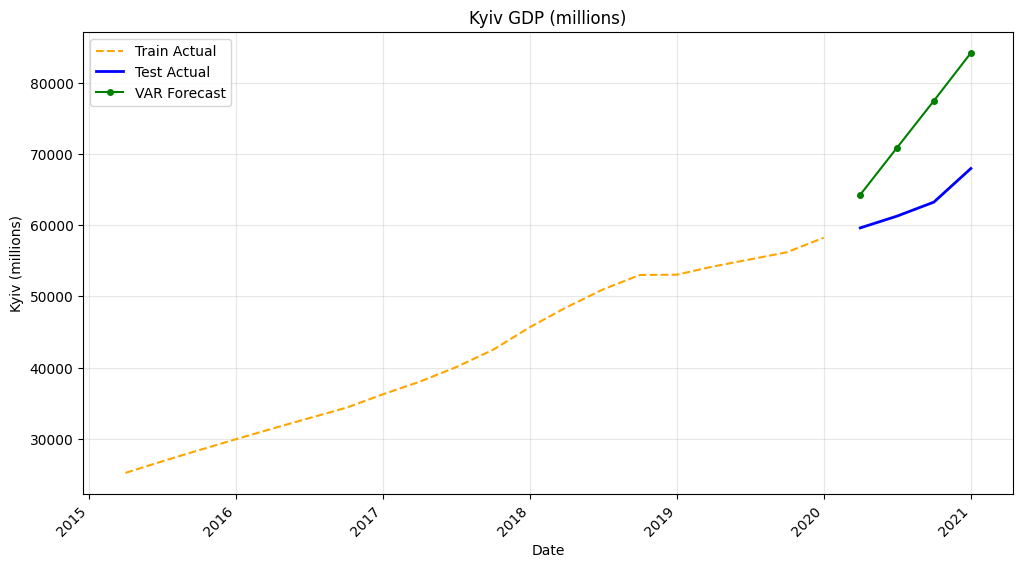

In [70]:
plt.figure(figsize=(12, 6))

plt.plot(train_data.index.to_timestamp(), var_data['kyiv_gdp'][1:-4], 
         label='Train Actual', color='orange', linestyle='--')

plt.plot(test_data.index.to_timestamp(), var_data['kyiv_gdp'][-4:], 
         label='Test Actual', color='blue', linewidth=2)

plt.plot(forecast_series.index.to_timestamp(), forecast_real.values, 
         label='VAR Forecast', color='green', marker='o', markersize=4)

plt.title('Kyiv GDP (millions)')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.xlabel('Date')
plt.ylabel('Kyiv (millions)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [92]:
forecast_series = pd.Series(forecast[:, 4], index=test_data.index)
last_log = var_data_log['infl_ukr_log'].iloc[-5]
forecast_log = last_log + forecast_series.cumsum()
forecast_real = np.exp(forecast_log)

print(forecast_real)

Показник
2020Q2    101.113431
2020Q3     99.518921
2020Q4     99.277356
2021Q1     98.569076
Freq: Q-DEC, dtype: float64


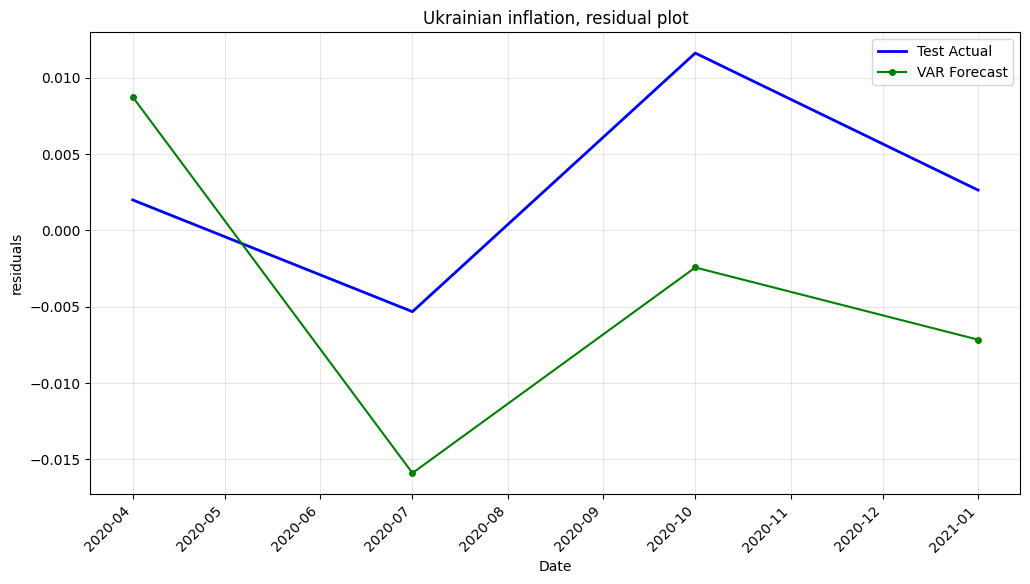

In [93]:

plt.figure(figsize=(12, 6))

#plt.plot(train_data.index.to_timestamp(), train_data['infl_ukr_log'], 
#         label='Train Actual', color='orange', linestyle='--')

plt.plot(test_data.index.to_timestamp(), test_data['infl_ukr_log'], 
         label='Test Actual', color='blue', linewidth=2)

plt.plot(forecast_series.index.to_timestamp(), forecast_series.values, 
         label='VAR Forecast', color='green', marker='o', markersize=4)

plt.title('Ukrainian inflation, residual plot')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.xlabel('Date')
plt.ylabel('residuals')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

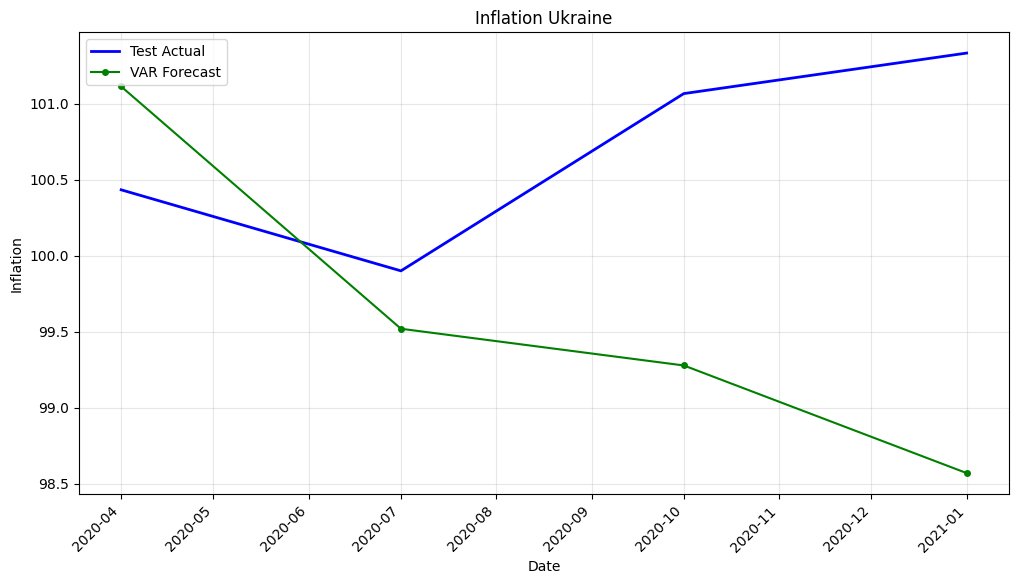

In [94]:
plt.figure(figsize=(12, 6))

#plt.plot(train_data.index.to_timestamp(), var_data['infl_ukr'][1:-4], 
#         label='Train Actual', color='orange', linestyle='--')

plt.plot(test_data.index.to_timestamp(), var_data['infl_ukr'][-4:], 
         label='Test Actual', color='blue', linewidth=2)

plt.plot(forecast_series.index.to_timestamp(), forecast_real.values, 
         label='VAR Forecast', color='green', marker='o', markersize=4)

plt.title('Inflation Ukraine')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.xlabel('Date')
plt.ylabel('Inflation')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [36]:
irf = results_train.irf(periods=10)

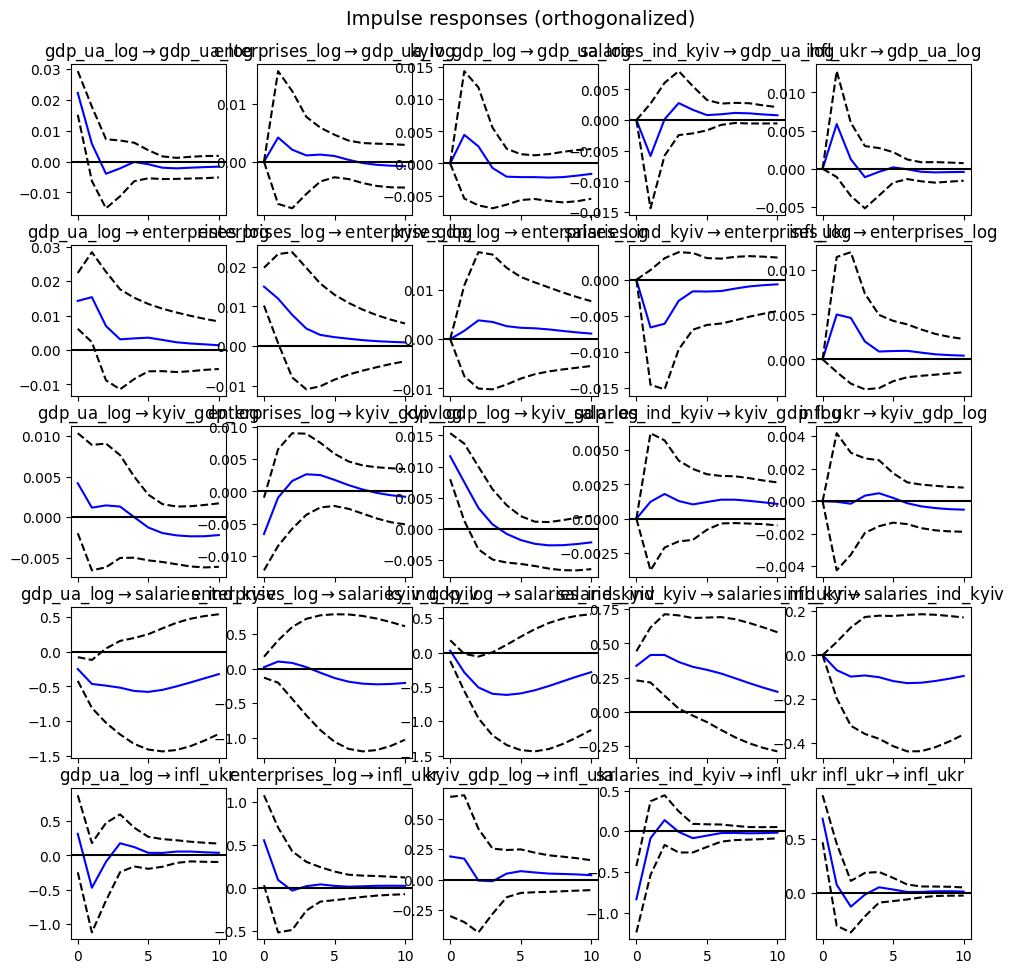

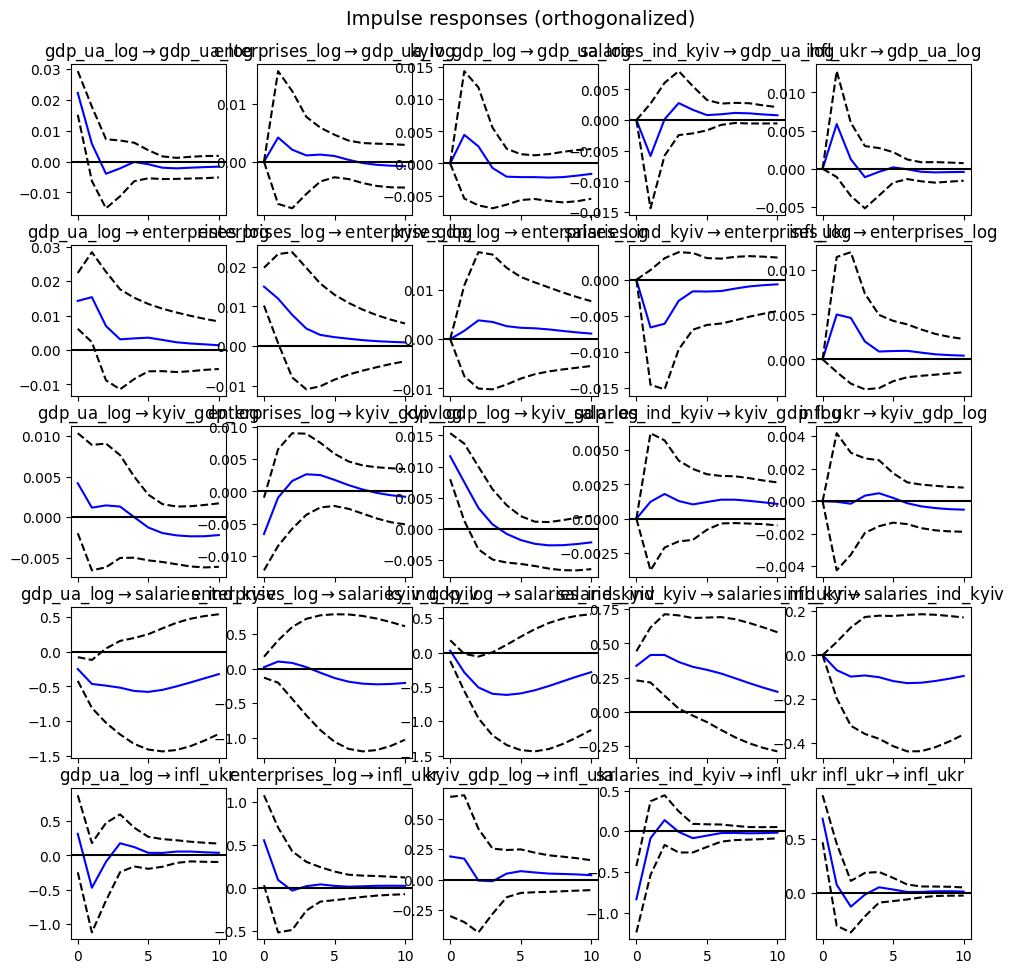

In [37]:
irf.plot(orth=True)

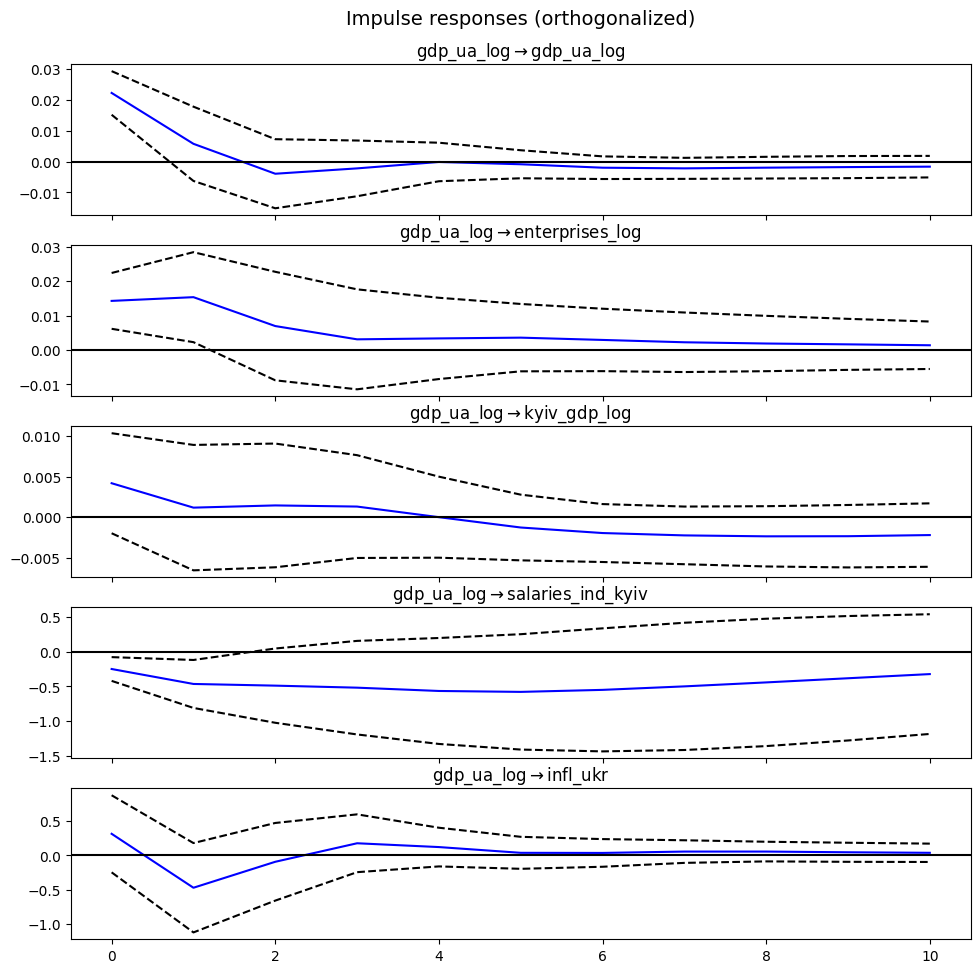

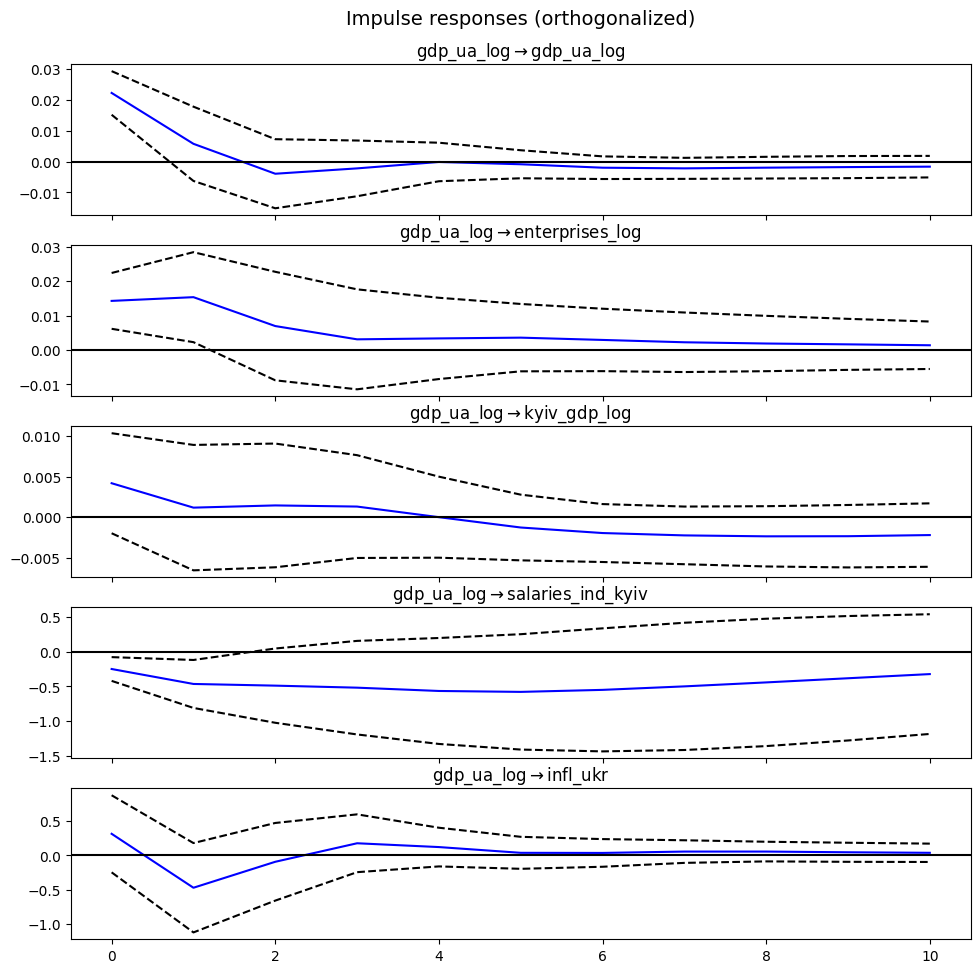

In [38]:
irf.plot(impulse='gdp_ua_log', orth=True, figsize=(10, 10))

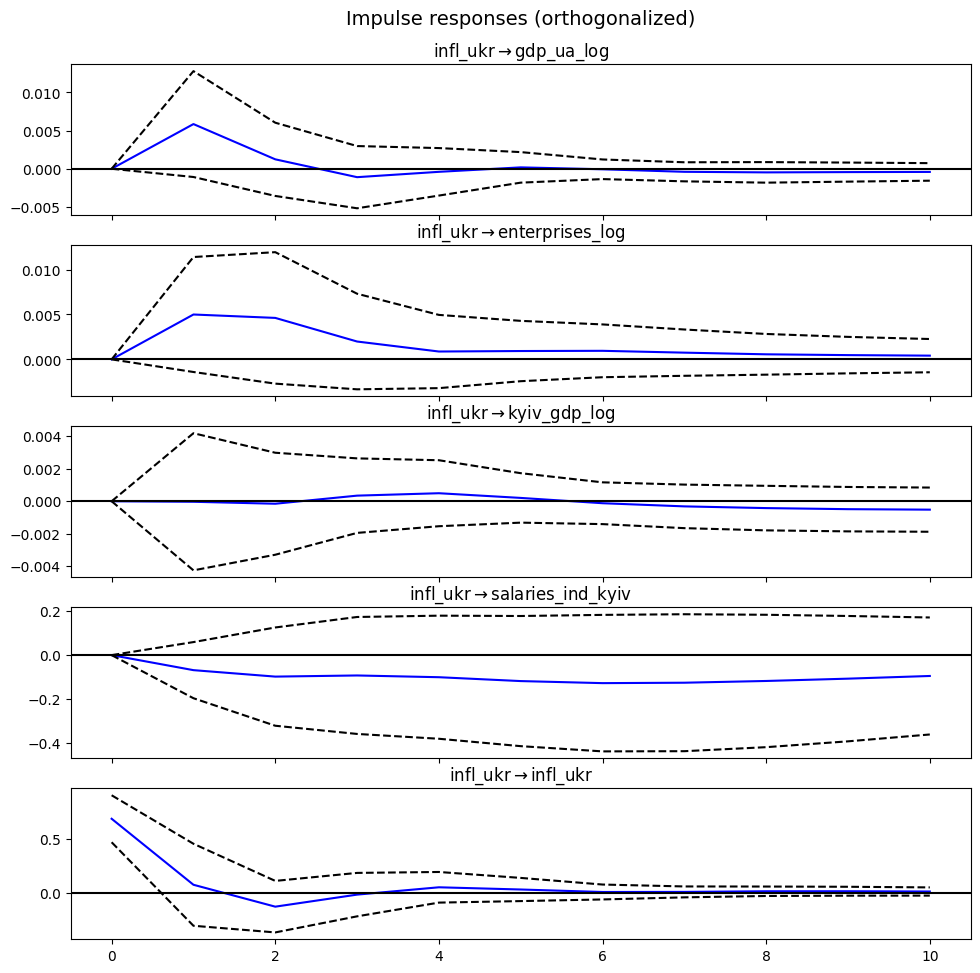

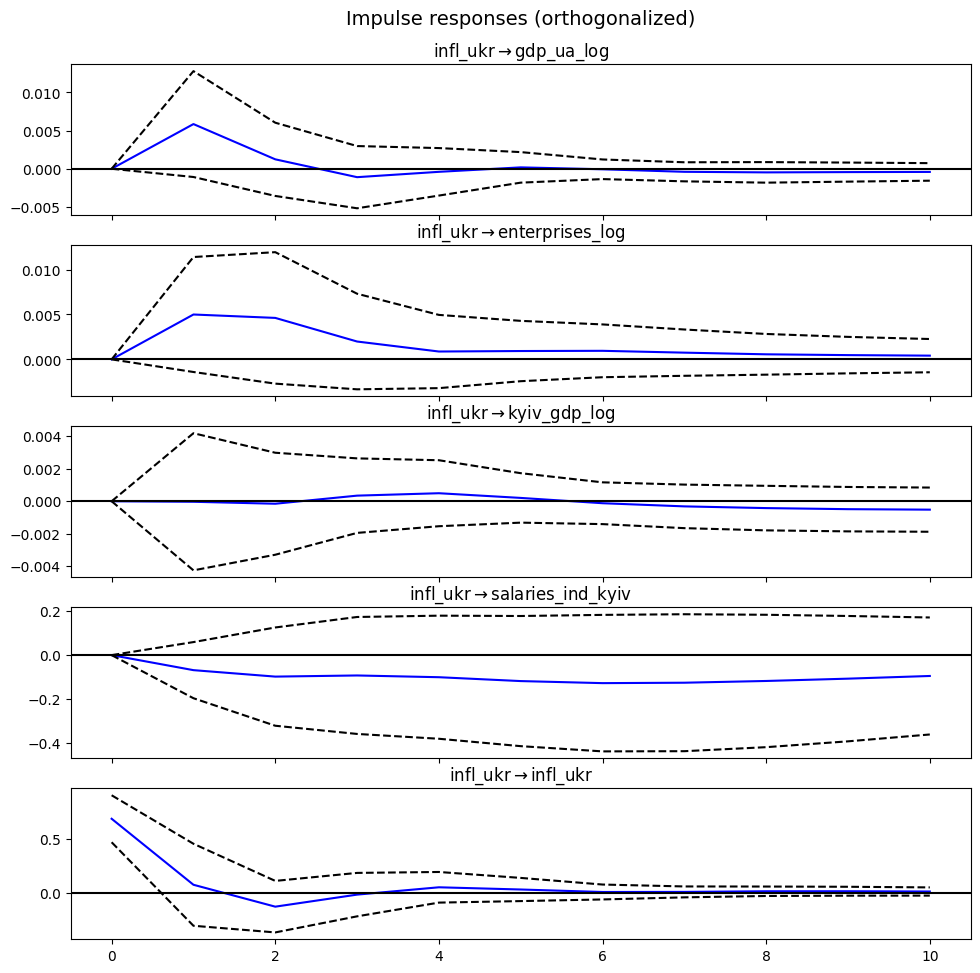

In [39]:
irf.plot(impulse='infl_ukr', orth=True, figsize=(10, 10))

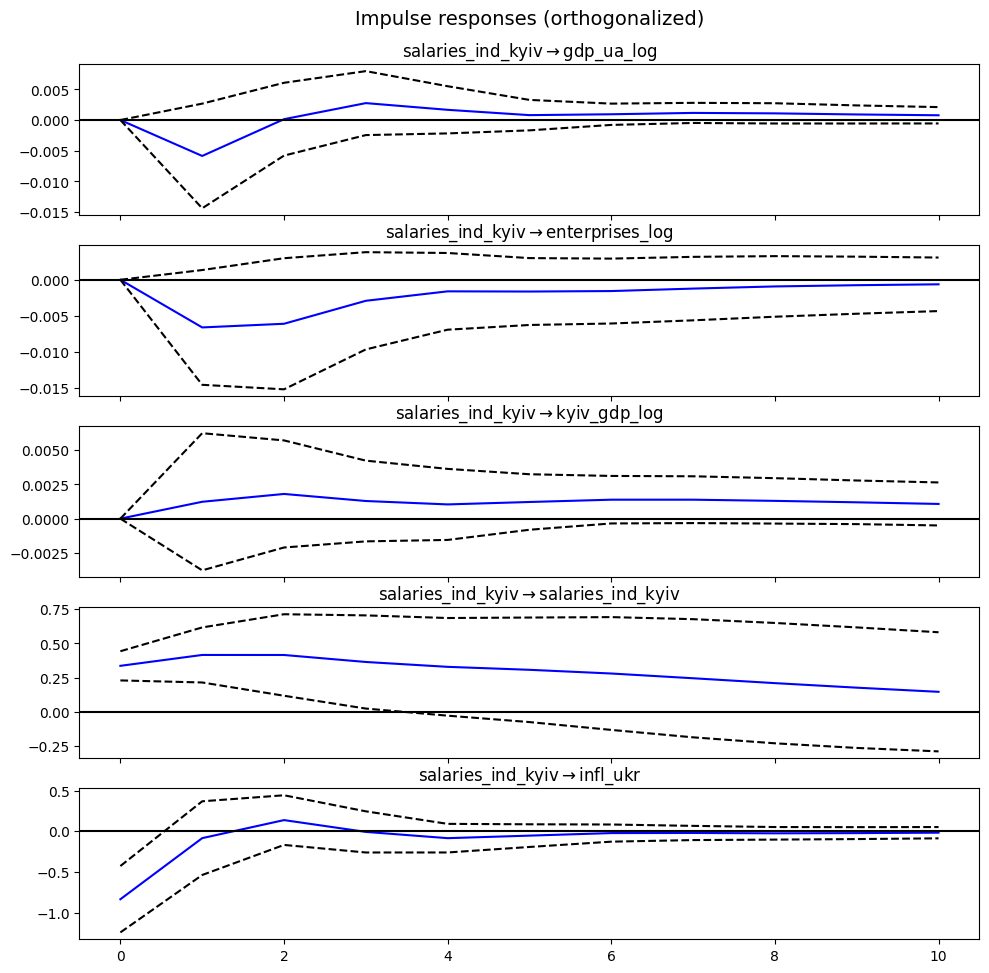

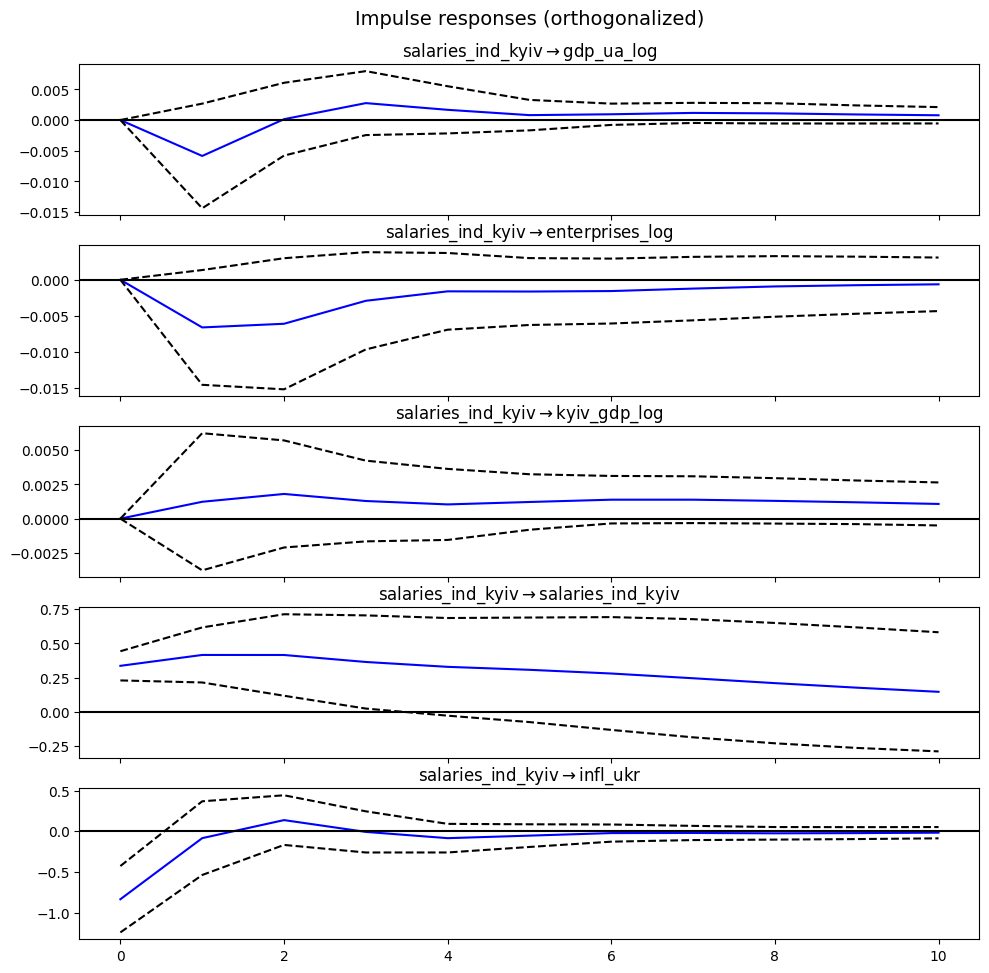

In [80]:
irf.plot(impulse='salaries_ind_kyiv', orth=True, figsize=(10, 10))